In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from typing import List, Dict
from typing import Dict, List

In [255]:
acc1 = pd.read_csv('../data/acc1.csv')
acc2 = pd.read_csv('../data/acc2.csv')

In [256]:
acc1["Account"] = "Chequing"
acc2["Account"] = "Savings"

bank_df_raw = pd.concat([acc1, acc2], ignore_index=True)

### First filter (coolumns)

In [257]:
bank_df = bank_df_raw.drop(columns=["Filter", "Type of Transaction"])

### Second filter (removing internal trasactions)

In [258]:
bank_df = bank_df[bank_df["Description"] != "customer transfer cr."]
bank_df = bank_df[bank_df["Description"] != "customer transfer dr."]

In [259]:
bank_df["Sub-description"] = (
    bank_df["Sub-description"]
    .fillna("none")         # fill NaN
    .replace("", "none")    # fill empty strings
)

# fill when there is just spaces 
bank_df.loc[bank_df["Sub-description"].str.strip() == "", "Sub-description"] = "none"

### Dropping the initial deposits and parent's deposits

In [260]:
bank_df = bank_df[~((bank_df["Description"] == "deposit") & (bank_df["Sub-description"] == "none"))]
bank_df = bank_df[bank_df["Description"] != "abm deposit"]
bank_df = bank_df.drop(index=[400, 397, 389, 349])

In [261]:
def classify_transactions(df: pd.DataFrame) -> pd.DataFrame:
    """Classify transactions into Class, Category, and Sub-Category columns."""
    df = df.copy()

    df["Class"] = "Expenses"
    df["Category"] = "Others"
    df["Sub-Category"] = "None"

    desc = df["Description"].fillna("").str.lower()
    sub_desc = df["Sub-description"].fillna("").str.lower()

    payroll_mask = desc == "payroll deposit"
    df.loc[payroll_mask, "Class"] = "Earnings"
    df.loc[payroll_mask, "Category"] = "Payment"

    correction_mask = desc == "correction"
    df.loc[correction_mask, "Class"] = "Earnings"
    df.loc[correction_mask, "Category"] = "earnings"

    interest_mask = desc == "interest"
    df.loc[interest_mask, "Class"] = "Earnings"
    df.loc[interest_mask, "Category"] = "earnings"

    deposit_mask = desc == "deposit"
    df.loc[deposit_mask, "Class"] = "Earnings"
    df.loc[deposit_mask, "Category"] = "shared bills"
    deposit_payment_mask = deposit_mask & df["Amount"].between(300, 900, inclusive="neither")
    df.loc[deposit_payment_mask, "Category"] = "Payment"

    withdrawal_mask = desc == "withdrawal"
    special_indices_mask = withdrawal_mask & df.index.isin({399, 352, 289})
    df.loc[special_indices_mask, "Category"] = "Shopping"

    rent_mask = withdrawal_mask & ~special_indices_mask & (df["Amount"] == -1200)
    df.loc[rent_mask, "Category"] = "Bills"
    df.loc[rent_mask, "Sub-Category"] = "Rent"

    other_withdrawal_mask = withdrawal_mask & ~(special_indices_mask | rent_mask)
    df.loc[other_withdrawal_mask, "Category"] = "money sent"

    pos_purchase_mask = desc == "pos purchase"
    compass_mask = pos_purchase_mask & sub_desc.str.startswith("compass")
    df.loc[compass_mask, "Category"] = "Bills"
    df.loc[compass_mask, "Sub-Category"] = "Transport"

    walmart_mask = pos_purchase_mask & sub_desc.str.startswith("walmart")
    df.loc[walmart_mask, "Category"] = "Groceries"

    real_cdn_mask = pos_purchase_mask & sub_desc.str.startswith("real cdn")
    df.loc[real_cdn_mask, "Category"] = "Groceries"

    bill_payment_mask = desc == "bill payment"
    df.loc[bill_payment_mask, "Category"] = "Bills"
    df.loc[bill_payment_mask, "Sub-Category"] = "Cellphone"

    service_charge_mask = desc == "service charge"
    df.loc[service_charge_mask, "Category"] = "Bills"
    df.loc[service_charge_mask, "Sub-Category"] = "Bank"

    return df

def validate_classification(
    df: pd.DataFrame,
    cols=("Class", "Category", "Sub-Category"),
    context_cols=("Description", "Sub-description", "Amount"),
    strip_whitespace=True,
    raise_on_error=False,
    sample=10,
):
    """
    Validate that classification columns are filled (not NaN/empty/whitespace).

    Returns:
        issues_df (pd.DataFrame): rows where at least one of `cols` is empty.
    """
    # Work on a view for checks, keep original intact
    chk = df.copy()

    # Optionally strip whitespace (common hidden culprit)
    if strip_whitespace:
        for c in cols:
            if c in chk.columns:
                chk[c] = chk[c].astype(str).str.strip()
                # Preserve NaN (str(NaN) -> 'nan'), so fix back:
                chk.loc[df[c].isna(), c] = np.nan

    # Build empty masks per column
    masks = {}
    for c in cols:
        if c not in chk.columns:
            raise ValueError(f"Column '{c}' not found in DataFrame.")
        masks[c] = chk[c].isna() | (chk[c] == "")

    # Any empty among the tracked columns
    any_empty = np.column_stack([masks[c] for c in cols]).any(axis=1)
    issues_df = chk.loc[any_empty, list(cols) + [col for col in context_cols if col in chk.columns]].copy()

    # Summary
    print("=== Classification Validator ===")
    for c in cols:
        cnt = int(masks[c].sum())
        print(f"- Empty in '{c}': {cnt}")
    print(f"- Rows with any empty among {list(cols)}: {len(issues_df)}")

    # Show a small sample to help debug
    if len(issues_df) > 0:
        print("\nSample of problematic rows:")
        display(issues_df.head(sample))

    if raise_on_error and len(issues_df) > 0:
        raise AssertionError("Empty values found in classification columns.")

    return issues_df

def normalize_text(s: str) -> str:
    t = (str(s) or "").lower().strip()
    t = re.sub(r"\s+", " ", t)
    return t

def classify_pos_purchase_generic(df: pd.DataFrame, rules: List[Dict]) -> pd.DataFrame:
    df = df.copy()
    # normalize once
    is_pos = df["Description"].fillna("").str.lower().eq("pos purchase")
    sub_norm = df["Sub-description"].fillna("").map(normalize_text)

    # ensure columns exist
    if "Category" not in df.columns:
        df["Category"] = "Others"
    if "Sub-Category" not in df.columns:
        df["Sub-Category"] = "None"

    # sort rules by priority
    rules_sorted = sorted(rules, key=lambda r: r.get("priority", 9999))

    # compile regexes
    for r in rules_sorted:
        if r.get("match_type") == "regex":
            r["_compiled"] = re.compile(r["pattern"], flags=re.I)

    # apply first-match-wins
    matched = pd.Series(False, index=df.index)
    for r in rules_sorted:
        pattern = r["pattern"].lower()
        match_type = r.get("match_type")
        if match_type == "startswith":
            mask = is_pos & ~matched & sub_norm.str.startswith(pattern)
        elif match_type == "regex":
            mask = is_pos & ~matched & sub_norm.str.match(r["_compiled"])
        else:  # contains (default)
            mask = is_pos & ~matched & sub_norm.str.contains(re.escape(pattern), regex=True)

        if mask.any():
            df.loc[mask, "Category"] = r["category"]
            df.loc[mask, "Sub-Category"] = r.get("sub_category", "None")
            matched |= mask

    # Final category consolidation
    original_category = df["Category"].copy()

    remap = {
        "Retail": "Shopping",
        "Online": "Shopping",
        "Household": "Groceries",
        "Convenience": "Groceries",
    }

    df["Category"] = df["Category"].replace(remap)

    special_rules = {
        "Alcohol": ("Groceries", "Alcohool"),
        "Coffee": ("Eating Out", "Coffee"),
        "Personal Care": ("Others", "Hair cut"),
    }

    for source, (target_category, target_sub_category) in special_rules.items():
        mask = original_category == source
        if mask.any():
            df.loc[mask, "Category"] = target_category
            df.loc[mask, "Sub-Category"] = target_sub_category

    return df

# Exemplo de “rules” (pode vir de CSV)
rules = [
    # Transport (Compass)
    {"pattern": "compass", "category": "Bills", "sub_category": "Transport", "priority": 1, "match_type": "startswith"},
    {"pattern": "compass vending", "category": "Bills", "sub_category": "Transport", "priority": 1, "match_type": "contains"},
    # Groceries (supermercados)
    {"pattern": "walmart", "category": "Groceries", "sub_category": "None", "priority": 5, "match_type": "contains"},
    {"pattern": "real cdn supers", "category": "Groceries", "sub_category": "None", "priority": 5, "match_type": "contains"},
    {"pattern": "save on foods", "category": "Groceries", "sub_category": "None", "priority": 5, "match_type": "contains"},
    {"pattern": "t t supermarket", "category": "Groceries", "sub_category": "None", "priority": 5, "match_type": "contains"},
    {"pattern": "h-mart", "category": "Groceries", "sub_category": "None", "priority": 5, "match_type": "contains"},
    {"pattern": "costco wholesal", "category": "Groceries", "sub_category": "None", "priority": 5, "match_type": "contains"},
    {"pattern": "urban fare", "category": "Groceries", "sub_category": "None", "priority": 5, "match_type": "contains"},
    # Discount / Household
    {"pattern": "dollarama", "category": "Household", "sub_category": "Discount", "priority": 6, "match_type": "contains"},
    {"pattern": "dollar tree", "category": "Household", "sub_category": "Discount", "priority": 6, "match_type": "contains"},
    {"pattern": "daiso", "category": "Household", "sub_category": "Discount", "priority": 6, "match_type": "contains"},
    # Eating out / Coffee / Desserts
    {"pattern": "mcdonald", "category": "Eating Out", "sub_category": "Fast Food", "priority": 10, "match_type": "contains"},
    {"pattern": "kfc", "category": "Eating Out", "sub_category": "Fast Food", "priority": 10, "match_type": "contains"},
    {"pattern": "popeyes", "category": "Eating Out", "sub_category": "Fast Food", "priority": 10, "match_type": "contains"},
    {"pattern": "subway", "category": "Eating Out", "sub_category": "Fast Food", "priority": 10, "match_type": "contains"},
    {"pattern": "fatburger", "category": "Eating Out", "sub_category": "Burgers", "priority": 11, "match_type": "contains"},
    {"pattern": "freshslice", "category": "Eating Out", "sub_category": "Pizza", "priority": 11, "match_type": "contains"},
    {"pattern": "ramen", "category": "Eating Out", "sub_category": "Asian", "priority": 12, "match_type": "contains"},
    {"pattern": "sushi", "category": "Eating Out", "sub_category": "Asian", "priority": 12, "match_type": "contains"},
    {"pattern": "shawarma", "category": "Eating Out", "sub_category": "Middle Eastern", "priority": 12, "match_type": "contains"},
    {"pattern": "tim hortons", "category": "Coffee", "sub_category": "Cafe", "priority": 13, "match_type": "contains"},
    {"pattern": "starbucks", "category": "Coffee", "sub_category": "Cafe", "priority": 13, "match_type": "contains"},
    {"pattern": "lee's donut", "category": "Eating Out", "sub_category": "Dessert", "priority": 14, "match_type": "contains"},
    {"pattern": "rain or shi", "category": "Eating Out", "sub_category": "Dessert", "priority": 14, "match_type": "contains"},
    # Convenience / Liquor
    {"pattern": "7-eleven", "category": "Groceries", "sub_category": "None", "priority": 20, "match_type": "contains"},
    {"pattern": "ins market", "category": "Groceries", "sub_category": "None", "priority": 20, "match_type": "contains"},
    {"pattern": "liquor", "category": "Alcohol", "sub_category": "None", "priority": 21, "match_type": "contains"},
    # Retail
    {"pattern": "best buy", "category": "Retail", "sub_category": "Electronics", "priority": 30, "match_type": "contains"},
    {"pattern": "london drugs", "category": "Retail", "sub_category": "Pharmacy", "priority": 30, "match_type": "contains"},
    {"pattern": "winners", "category": "Retail", "sub_category": "Apparel", "priority": 30, "match_type": "contains"},
    {"pattern": "sephora", "category": "Retail", "sub_category": "Beauty", "priority": 30, "match_type": "contains"},
    {"pattern": "decathlon", "category": "Retail", "sub_category": "Sports", "priority": 30, "match_type": "contains"},
    {"pattern": "sport chek", "category": "Retail", "sub_category": "Sports", "priority": 30, "match_type": "contains"},
    {"pattern": "uniqlo", "category": "Retail", "sub_category": "Apparel", "priority": 30, "match_type": "contains"},
    {"pattern": "nike", "category": "Retail", "sub_category": "Apparel", "priority": 30, "match_type": "contains"},
    {"pattern": "north face", "category": "Retail", "sub_category": "Apparel", "priority": 30, "match_type": "contains"},
    {"pattern": "browns shoes", "category": "Retail", "sub_category": "Shoes", "priority": 30, "match_type": "contains"},
    # Online merchants
    {"pattern": "amzn mktp", "category": "Online", "sub_category": "Amazon", "priority": 40, "match_type": "contains"},
    {"pattern": "aliexpress", "category": "Online", "sub_category": "AliExpress", "priority": 40, "match_type": "contains"},
    {"pattern": "temu", "category": "Online", "sub_category": "Temu", "priority": 40, "match_type": "contains"},
    {"pattern": "name-cheap", "category": "Online", "sub_category": "Domains", "priority": 41, "match_type": "contains"},
    {"pattern": "openai", "category": "Online", "sub_category": "Services", "priority": 41, "match_type": "contains"},
    # Hair / Personal care
    {"pattern": "hair salon", "category": "Personal Care", "sub_category": "Salon", "priority": 50, "match_type": "contains"},
]

# Uso:
# bank_df = classify_pos_purchase_generic(bank_df, rules)

In [262]:
# Depois de rodar sua classify_transactions:
bank_df = classify_transactions(bank_df)

# Validar:
issues = validate_classification(bank_df)

# Se quiser "falhar" o notebook quando houver problema:
# issues = validate_classification(bank_df, raise_on_error=True)
# 1) Versão generalizável (com 'rules'):
bank_df = classify_pos_purchase_generic(bank_df, rules) 

=== Classification Validator ===
- Empty in 'Class': 0
- Empty in 'Category': 0
- Empty in 'Sub-Category': 0
- Rows with any empty among ['Class', 'Category', 'Sub-Category']: 0


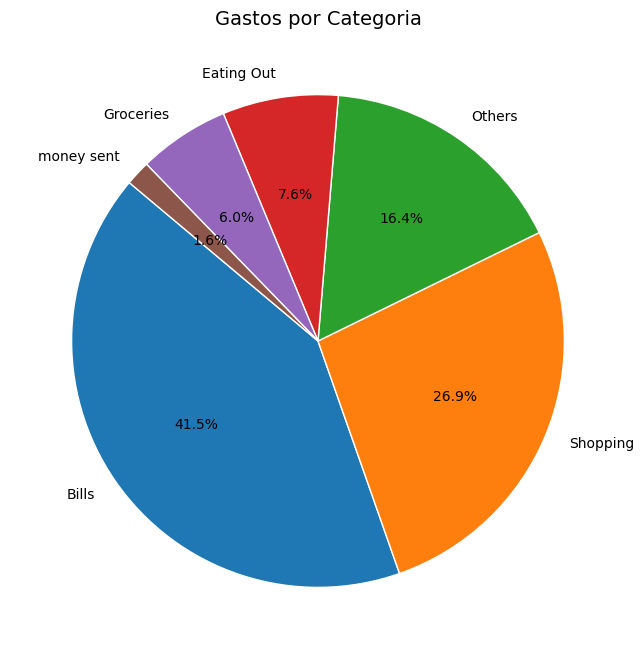

In [263]:
# garantir que Category está preenchido
if "Category" not in bank_df.columns:
    raise ValueError("Category column not found. Run classification first.")

# agregando gastos por categoria (usando valor absoluto do Amount)
category_expenses = (
    bank_df[bank_df["Class"] == "Expenses"]
    .groupby("Category")["Amount"]
    .sum()
    .abs()
)

# ordena para ficar mais bonito
category_expenses = category_expenses.sort_values(ascending=False)

# gráfico de pizza
plt.figure(figsize=(8, 8))
plt.pie(
    category_expenses,
    labels=category_expenses.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
plt.title("Gastos por Categoria", fontsize=14)
plt.show()

In [264]:
# analisar others

# Alcohool -> Convenience and Sub-category = Alcohool
# Coffee -> Eating out and Sub-category = Coffee.
# Personal care -> Others and Sub-category = Hair cut
bank_df[bank_df['Category'] == 'Others']

,Date,Description,Sub-description,Amount,Balance,Account,Class,Category,Sub-Category
8,2025-09-22,pos purchase,Apos Global Harbor C Burna,-3.55,4299.22,Chequing,Expenses,Others,None
9,2025-09-22,pos purchase,Apos Romano'S Pizza Vanco,-5.50,4302.77,Chequing,Expenses,Others,None
14,2025-09-20,pos purchase,Apos Blenz At Librar Vanco,-5.15,4343.18,Chequing,Expenses,Others,None
15,2025-09-19,pos purchase,Apos Bbq Chicken And Vanco,-42.30,4348.33,Chequing,Expenses,Others,None
19,2025-09-19,pos purchase,Opos Abc*32130 Fw Downtow888-8,-15.74,4000.14,Chequing,Expenses,Others,None
...,...,...,...,...,...,...,...,...,...
344,2025-05-13,pos purchase,Apos Taco Bell 6802 Vanco,-8.07,5814.76,Chequing,Expenses,Others,None
346,2025-05-12,pos purchase,Apos A W #0770 Granv Vanco,-4.45,5875.31,Chequing,Expenses,Others,None
354,2025-05-12,pos purchase,Apos Shoprite Smoke Vanco,-0.99,935.59,Chequing,Expenses,Others,None
357,2025-05-09,pos purchase,Apos Tst-Jerusalem S Vanco,-17.20,977.56,Chequing,Expenses,Others,None


In [265]:
bank_df['Category'].unique()

array(['Payment', 'money sent', 'Groceries', 'Shopping', 'Others',
       'Eating Out', 'Bills', 'earnings', 'shared bills'], dtype=object)